# 05_get_sequences_align_and_analyse_conservation

Scaffold notebook for sequence/structure alignment, MSA visualization, and optional conservation analysis.


## Python Path Setup


In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
repo_root = cwd.parent if cwd.name == "notebooks" else cwd
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
src_root = repo_root / "src"
if src_root.exists() and str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))


## Imports


In [2]:
import importlib
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

import agentic_protein_design.steps.get_sequences_align_and_analyse_conservation as align_step
align_step = importlib.reload(align_step)

default_user_inputs = align_step.default_user_inputs
run_alignment_and_conservation = align_step.run_alignment_and_conservation


## Workflow Skeleton

1. Choose `align_mode`: sequence alignment (`seq`) or structural alignment (`struct`).
2. Build or reuse an MSA, then optionally convert it to a dataframe.
3. Visualize the MSA and optionally run conservation analysis.


## User Inputs (Edit This Cell)


In [7]:
user_inputs = default_user_inputs()

# Data root key from project_config/variables.py (address_dict)
user_inputs["root_key"] = "examples"
user_inputs["data_subfolder"] = ""

# Alignment mode:
# - "seq": sequence-based alignment via OpenProtein or local search + MAFFT
# - "struct": structural alignment of input PDBs via tools.yasara.align_struct_yasara.AlignStruct,
#             then export the structural alignment as a FASTA MSA
user_inputs["align_mode"] = "seq"

# If True, skip alignment and only run downstream steps on an existing MSA FASTA.
# Existing MSA source priority:
# 1) sequence_input if it is a .fasta file
# 2) {root}/msa/{data_subfolder}/msa_output_filename if already present
user_inputs["skip_align"] = True
user_inputs["run_conservation_analysis"] = False

# If True, export the MSA to a CSV dataframe (one row per alignment position).
user_inputs["convert_msa_to_dataframe"] = True

# Sequence-mode input only (used when align_mode = "seq"):
# - raw amino-acid string -> treated as a single seed sequence
# - .fasta filename with one sequence -> treated as a single seed sequence
# - .fasta filename with multiple sequences -> treated as a pre-collected homolog set for MAFFT
# FASTA files are resolved under {root}/{sequence_subdirectory}/{data_subfolder}/
user_inputs["sequence_input"] = "ET096.fasta" # "ET096.fasta" # "UPOpanel.fasta" # "UPO.fasta"
if user_inputs["align_mode"]=='seq':
    fname_base = user_inputs["sequence_input"].replace('.fasta', '') + '_aligned'

# Sequence-mode backend used only when sequence_input resolves to a single seed sequence:
# - "openprotein": fetch homologs + MSA via OpenProtein and also save ungapped homolog FASTA
# - "blastp", "phmmer", "jackhmmer": run local homolog search, parse hits, then align with MAFFT
user_inputs["homolog_search_backend"] = "openprotein"

# Local search settings (used for blastp/phmmer/jackhmmer)
# search_db_root_key points to the database root in address_dict (usually "databases")
user_inputs["search_db_root_key"] = "databases"
user_inputs["search_db_name"] = "uniprot_trembl"
user_inputs["search_e_thres"] = 1e-5
user_inputs["search_incE_thres"] = 1e-5
user_inputs["search_max_target_seqs"] = 250
user_inputs["search_num_cpu"] = None

# Structural-mode inputs (used when align_mode = "struct"):
# Provide at least two PDB filenames under {root}/{structure_subdirectory}/{data_subfolder}/
user_inputs["structure_pdb_filenames"] = [
    "ET096_S82.pdb",
    "CviUPO_S82.pdb",
    "DcaUPO_S82.pdb",
    "TE314_S82.pdb",
    "OA167_S82.pdb",
]
user_inputs["struct_alignment_sce_filename"] = "UPO_peroxygenation_aligned.sce"
if user_inputs["align_mode"]=='struct':
    fname_base = user_inputs["struct_alignment_sce_filename"].replace('.sce', '')

# Input and output filenames
# MSA FASTA, MSA CSV, plot PNG, and conservation_analysis CSV are saved under {root}/msa/{data_subfolder}/
# Homolog FASTA outputs are saved under {root}/sequences/{data_subfolder}/
user_inputs["msa_output_filename"] = fname_base + '.fasta'
user_inputs["msa_dataframe_output_filename"] = fname_base + '.csv'
user_inputs["seqsearch_output_filename"] = f'{fname_base}_homologs_{user_inputs["homolog_search_backend"]}.fasta'
user_inputs["plot_output_filename"] = fname_base
user_inputs["conservation_output_filename"] = fname_base + '_conservation.csv'

# Local MAFFT binary path or command name (used for MAFFT-based branches)
user_inputs["mafft_executable"] = str((repo_root / "tools" / "align" / "mafft-mac" / "mafft.bat").resolve())

# Visualization / conservation_analysis options
# The MSA image is generated via tools.align.visualize_alignment.visualize_msa
user_inputs["filter_by_refseq_or_idx"] = 'ET096' # None
user_inputs["indiv_seq_display_thres"] = 20
user_inputs["msa_plot_wrap_length"] = 81


user_inputs


{'mafft_executable': '/Users/charmainechia/Documents/projects/agentic-protein-design/tools/align/mafft-mac/mafft.bat',
 'root_key': 'examples',
 'data_subfolder': '',
 'align_mode': 'seq',
 'skip_align': True,
 'convert_msa_to_dataframe': True,
 'sequence_input': 'ET096.fasta',
 'structure_pdb_filenames': ['ET096_S82.pdb',
  'CviUPO_S82.pdb',
  'DcaUPO_S82.pdb',
  'TE314_S82.pdb',
  'OA167_S82.pdb'],
 'msa_output_filename': 'ET096_aligned.fasta',
 'msa_dataframe_output_filename': 'ET096_aligned.csv',
 'seqsearch_output_filename': 'ET096_aligned_homologs_openprotein.fasta',
 'struct_alignment_sce_filename': 'UPO_peroxygenation_aligned.sce',
 'plot_output_filename': 'ET096_aligned',
 'conservation_output_filename': 'ET096_aligned_conservation.csv',
 'homolog_search_backend': 'openprotein',
 'search_db_name': 'uniprot_trembl',
 'search_db_root_key': 'databases',
 'search_e_thres': 1e-05,
 'search_incE_thres': 1e-05,
 'search_max_target_seqs': 250,
 'search_num_cpu': None,
 'run_conservati

## Run Alignment Pipeline


Parsed sequence input kind: fasta_single
msa_out: /Users/charmainechia/Documents/projects/agentic-protein-design/examples/msa/ET096_aligned.fasta 2432


/Users/charmainechia/Documents/projects/agentic-protein-design/tools/align/visualize_alignment.py:148: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  msa_df[f'{seq}_resnum'] = resnum_list


filter_by_refseq_or_idx: ET096
Ref Seq: MKLTLLLSAVFSGAVATLAETSEWSPPESGDARSPCPLLNSLANHGYLPHDGKNITGDVLSKAITTTLNMDDSVSAAFMAALRNSITTAETFSLDELNKHNGIEHDASLSRQDFYFGNVQAFNETIFNQTRSYWTDPVTIDIHQAANARNARIETSKATNPTYNETAVNRASALETAAYILSFGDKVTGSVPKAFVEYFFENERLPFHLGWYKSAESISFADFQNMSTRVSQAGSQSPRAIEL


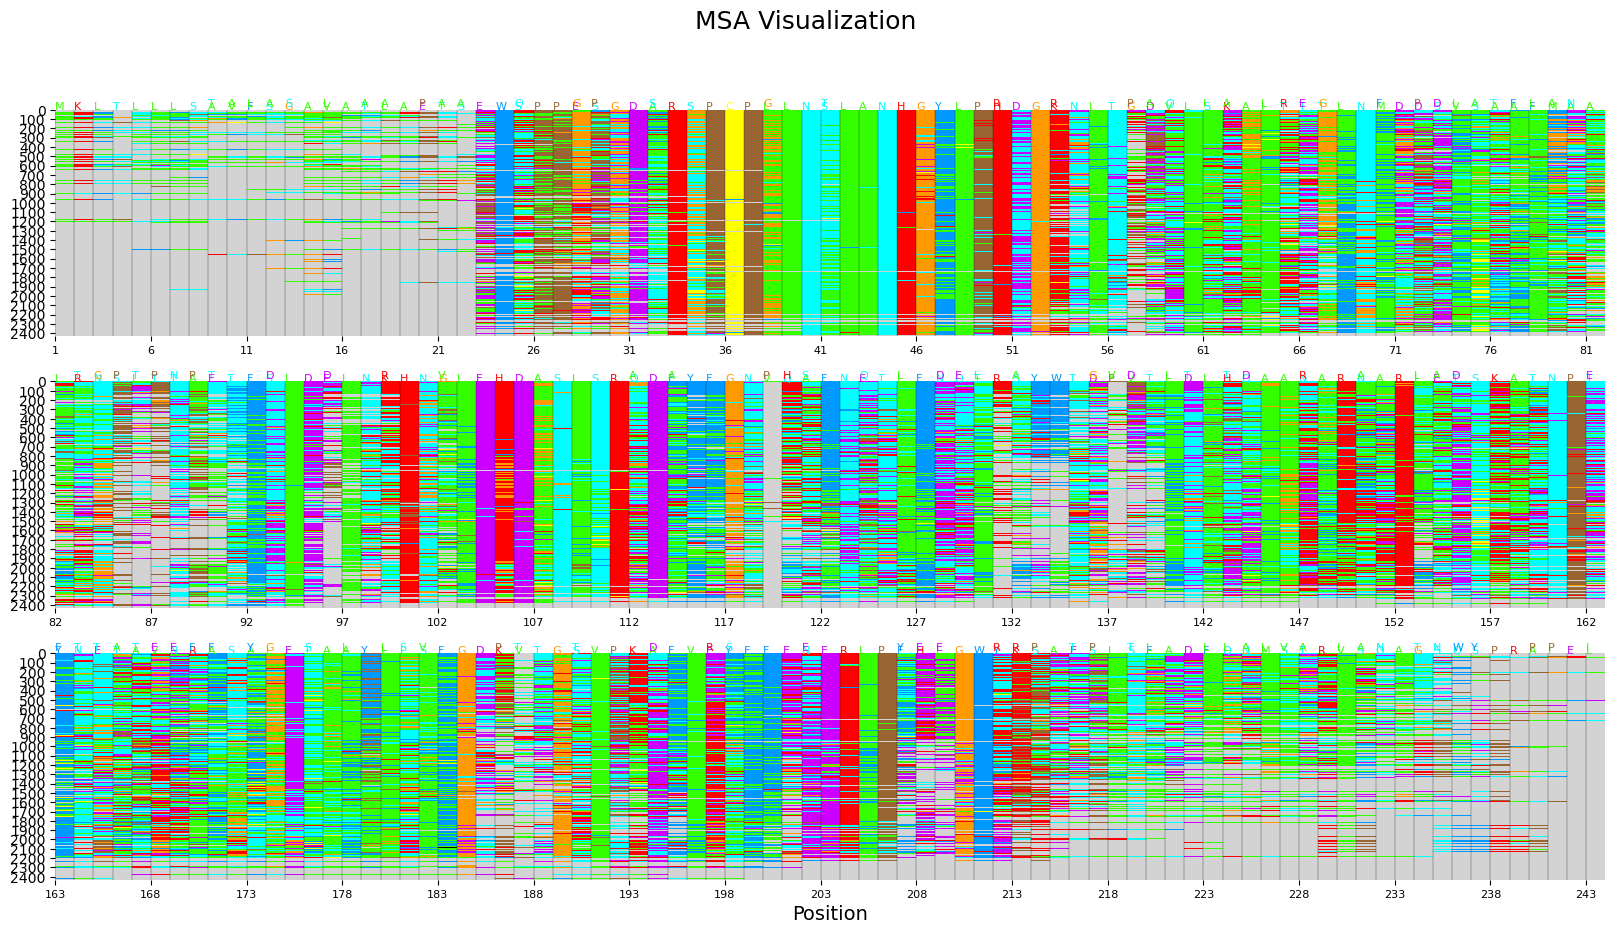

status: ok
align_mode: seq
input_kind: fasta_single
backend: 
message: Alignment step skipped; downstream MSA processing only.


In [8]:
result = run_alignment_and_conservation(user_inputs)
print("status:", result.get("status", ""))
print("align_mode:", result.get("align_mode", ""))
print("input_kind:", result.get("input_kind", ""))
print("backend:", result.get("alignment_backend", ""))
if result.get("message"):
    print("message:", result["message"])
